# TD : Apprentissage Non Supervisé
## Dataset : Wine Clustering (`mltrev23/wine-clustering` / sklearn)

**Objectifs :**
- Appliquer K-Means, DBSCAN et Isolation Forest sur des données réelles
- Optimiser les hyperparamètres via le score de silhouette
- Qualifier et interpréter les clusters obtenus

**Dataset :** 178 vins décrits par 13 propriétés chimiques (alcool, acidité, phénols, etc.)  
**Datamap (dictionnaire des données) :** 13 propriétés physico-chimiques mesurées sur chaque vin.

| Colonne | Description |
|---|---|
| Alcohol | Teneur en alcool |
| Malic Acid | Acide malique |
| Ash | Cendres (résidu minéral) |
| Alcalinity of Ash | Alcalinité des cendres |
| Magnesium | Teneur en magnésium |
| Total Phenols | Phénols totaux |
| Flavanoids | Flavonoïdes (sous-famille de phénols) |
| Nonflavanoid Phenols | Phénols non flavonoïdes |
| Proanthocyanins | Proanthocyanidines (tanins) |
| Color Intensity | Intensité de la couleur |
| Hue | Teinte |
| OD280/OD315 | Absorbance optique (mesure de pureté des protéines) |
| Proline | Teneur en proline (acide aminé) |

**Tâche :** Regrouper les vins sans utiliser les étiquettes : et voir si les groupes correspondent à des cépages réels.

---
## 0. Installation & Imports

In [33]:
# Si nécessaire : pip install datasets scikit-learn matplotlib seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import load_wine

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='tab10')
RANDOM_STATE = 42

---
## 1. Chargement des données

In [34]:
# Chargement via HuggingFace (ou fallback sklearn si offline)
try:
    from datasets import load_dataset
    hf_ds = load_dataset('mltrev23/wine-clustering', split='train')
    df_raw = hf_ds.to_pandas()
    print("Source : HuggingFace")
except Exception:
    wine = load_wine()
    df_raw = pd.DataFrame(wine.data, columns=wine.feature_names)
    # On conserve les vraies étiquettes à part : uniquement pour évaluation finale
    true_labels = wine.target
    print("Source : sklearn (même données)")

print(f"Shape : {df_raw.shape}")
df_raw.head()

Source : sklearn (même données)
Shape : (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [35]:
df_raw.describe().round(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


In [36]:
# Vérification : valeurs manquantes ?
print(df_raw.isnull().sum().sum(), "valeurs manquantes")

0 valeurs manquantes


---
## 2. Prétraitement

Les algorithmes de clustering (surtout K-Means et DBSCAN) sont sensibles aux échelles.  
On normalise toutes les features avec `StandardScaler` (moyenne=0, écart-type=1).

In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_raw)
X_scaled = pd.DataFrame(X_scaled, columns=df_raw.columns)

print("Moyenne après scaling :", X_scaled.mean().round(6).max())
print("Std après scaling    :", X_scaled.std().round(2).min())

Moyenne après scaling : 0.0
Std après scaling    : 1.0


### Réduction dimensionnelle pour la visualisation (PCA 2D)
On réduit à 2 composantes uniquement pour visualiser : les modèles tournent sur les 13 features.

Variance expliquée : PC1=36.2%, PC2=19.2%
Total : 55.4%


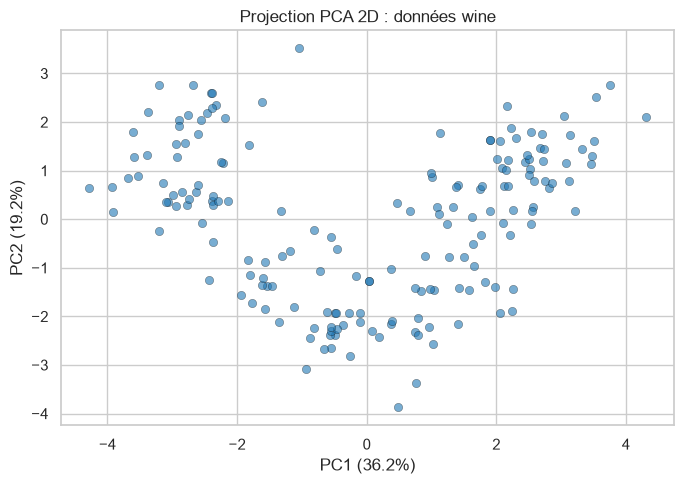

In [38]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance expliquée : PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
print(f"Total : {sum(pca.explained_variance_ratio_):.1%}")

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, edgecolors='k', linewidths=0.3)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Projection PCA 2D : données wine')
plt.tight_layout()
plt.show()

---
## 3. K-Means

### 3.1 Optimisation du nombre de clusters (k)
On teste k de 2 à 10 et on compare :
- **Inertie** (elbow method) : somme des distances au centroïde
- **Score de silhouette** : mesure de cohésion/séparation, entre -1 et 1 (plus élevé = mieux)

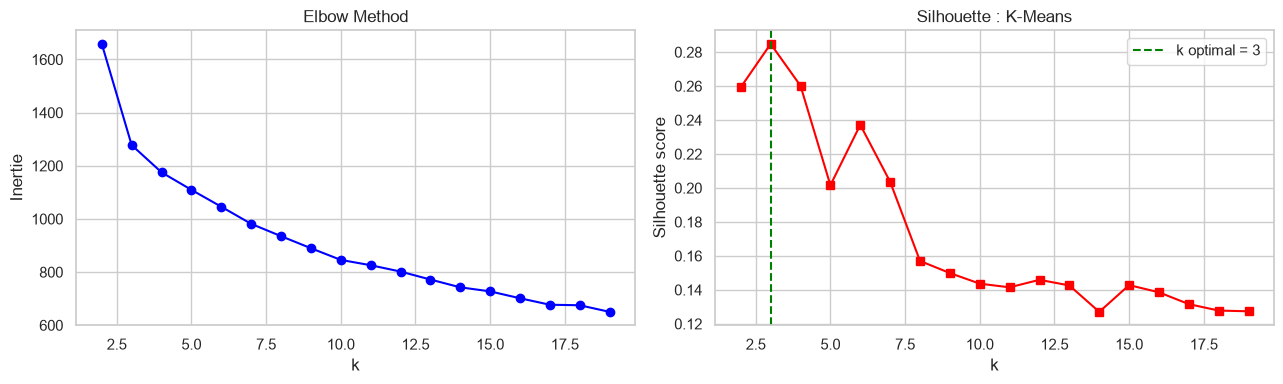

k optimal (silhouette max) : 3 → score = 0.2849


In [39]:
K_range = range(2, 20)
inertias = []
silhouettes_kmeans = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes_kmeans.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, silhouettes_kmeans, 'rs-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette : K-Means')

best_k = list(K_range)[np.argmax(silhouettes_kmeans)]
axes[1].axvline(best_k, color='green', linestyle='--', label=f'k optimal = {best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"k optimal (silhouette max) : {best_k} → score = {max(silhouettes_kmeans):.4f}")

### 3.2 Entraînement avec k optimal

In [40]:
km_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_kmeans = km_best.fit_predict(X_scaled)

print(f"Silhouette K-Means (k={best_k}) : {silhouette_score(X_scaled, labels_kmeans):.4f}")
print("Distribution des clusters :")
print(pd.Series(labels_kmeans).value_counts().sort_index())

Silhouette K-Means (k=3) : 0.2849
Distribution des clusters :
0    65
1    51
2    62
Name: count, dtype: int64


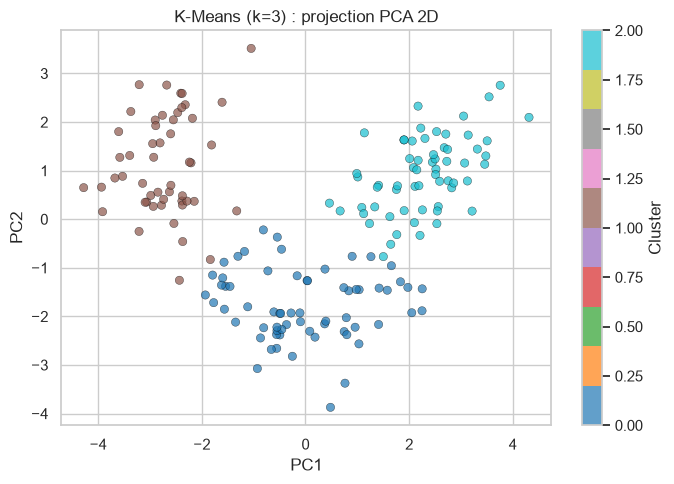

In [41]:
# Visualisation PCA
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap='tab10', alpha=0.7, edgecolors='k', linewidths=0.3)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means (k={best_k}) : projection PCA 2D')
plt.tight_layout()
plt.show()

### 3.3 Silhouette plot par échantillon

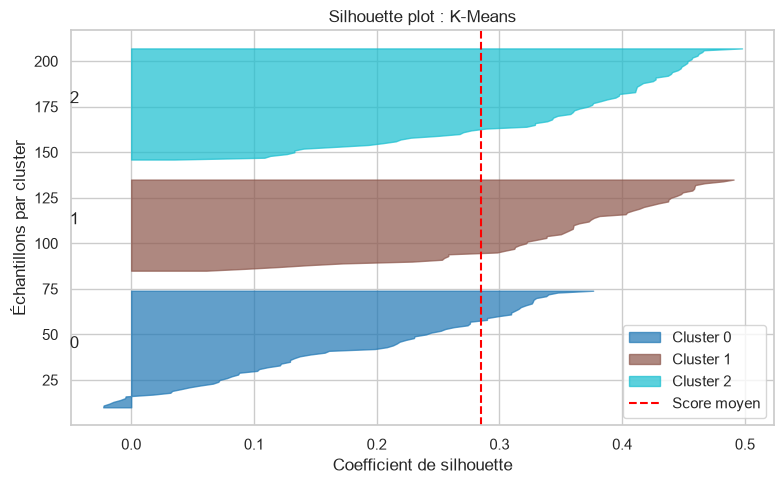

In [42]:
sample_silhouette_values = silhouette_samples(X_scaled, labels_kmeans)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, best_k))

for i in range(best_k):
    cluster_vals = np.sort(sample_silhouette_values[labels_kmeans == i])
    size = cluster_vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals, alpha=0.7, color=colors[i], label=f'Cluster {i}')
    ax.text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10

ax.axvline(x=silhouette_score(X_scaled, labels_kmeans), color='red', linestyle='--', label='Score moyen')
ax.set_xlabel('Coefficient de silhouette')
ax.set_ylabel('Échantillons par cluster')
ax.set_title('Silhouette plot : K-Means')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 4. DBSCAN

DBSCAN regroupe les points denses et marque les points isolés comme **bruit** (label = -1).  
Deux hyperparamètres clés :
- `eps` : rayon de voisinage
- `min_samples` : nombre minimum de voisins pour être un point core

### 4.1 Optimisation via grille eps × min_samples

In [43]:
from itertools import product

eps_values = np.arange(0.5, 3.0, 0.25)
min_samples_values = [3, 5, 7, 10]

results_dbscan = []

for eps, min_s in product(eps_values, min_samples_values):
    db = DBSCAN(eps=eps, min_samples=min_s)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    
    if n_clusters >= 2:
        sil = silhouette_score(X_scaled, labels)
        results_dbscan.append({'eps': eps, 'min_samples': min_s, 'n_clusters': n_clusters, 'n_noise': n_noise, 'silhouette': sil})

df_dbscan_results = pd.DataFrame(results_dbscan).sort_values('silhouette', ascending=False)
print(f"{len(df_dbscan_results)} configurations valides (≥2 clusters)")
df_dbscan_results.head(10)

12 configurations valides (≥2 clusters)


,eps,min_samples,n_clusters,n_noise,silhouette
11,2.50,10,2,32,0.204389
7,2.25,3,2,37,0.198443
8,2.25,5,2,46,0.165469
9,2.25,7,2,57,0.133591
10,2.25,10,2,75,0.091084
4,2.00,3,5,64,0.031407
6,2.00,7,3,110,-0.027448
5,2.00,5,5,85,-0.032906
1,1.75,3,11,98,-0.124735
3,1.75,7,2,164,-0.158270


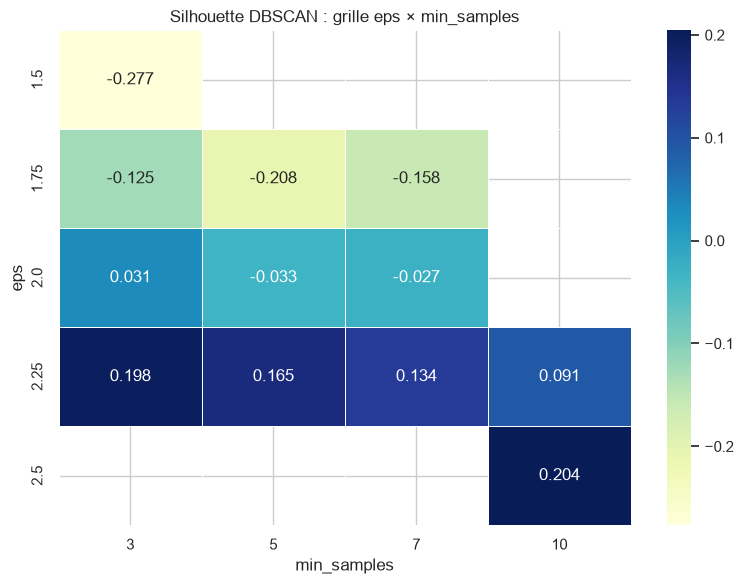

In [44]:
# Heatmap silhouette
pivot = df_dbscan_results.pivot_table(index='eps', columns='min_samples', values='silhouette', aggfunc='max')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', linewidths=0.5)
plt.title('Silhouette DBSCAN : grille eps × min_samples')
plt.tight_layout()
plt.show()

### 4.2 Entraînement avec les meilleurs paramètres

In [45]:
best_dbscan = df_dbscan_results.iloc[0]
print(f"Meilleurs paramètres : eps={best_dbscan['eps']:.2f}, min_samples={int(best_dbscan['min_samples'])}")
print(f"Clusters : {int(best_dbscan['n_clusters'])} | Bruit : {int(best_dbscan['n_noise'])} points | Silhouette : {best_dbscan['silhouette']:.4f}")

db_best = DBSCAN(eps=best_dbscan['eps'], min_samples=int(best_dbscan['min_samples']))
labels_dbscan = db_best.fit_predict(X_scaled)

Meilleurs paramètres : eps=2.50, min_samples=10
Clusters : 2 | Bruit : 32 points | Silhouette : 0.2044


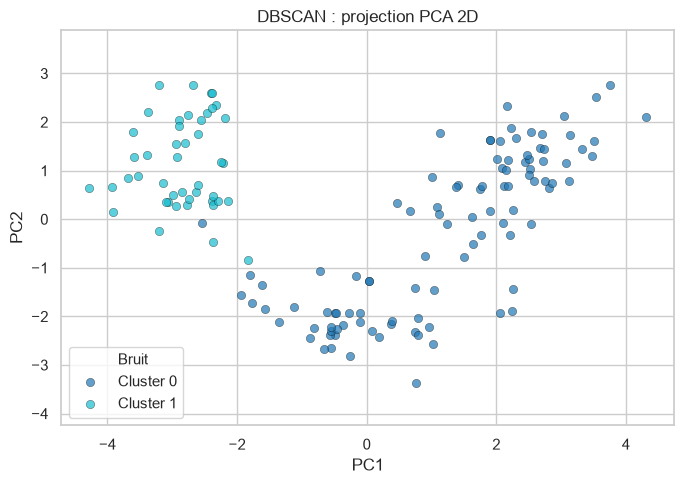

In [46]:
plt.figure(figsize=(7, 5))
unique_labels = sorted(set(labels_dbscan))
cmap = plt.cm.tab10

for label in unique_labels:
    mask = labels_dbscan == label
    color = 'black' if label == -1 else cmap(label / max(unique_labels + [1]))
    marker = 'x' if label == -1 else 'o'
    name = 'Bruit' if label == -1 else f'Cluster {label}'
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], marker=marker, alpha=0.7, label=name, edgecolors='k', linewidths=0.3 if label != -1 else 0)

plt.legend()
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN : projection PCA 2D')
plt.tight_layout()
plt.show()

---
## 5. Isolation Forest

Isolation Forest est un algorithme de **détection d'anomalies** :  
il isole les points atypiques (vins aux propriétés chimiques inhabituelles) en construisant des arbres de décision aléatoires.  
Un point est d'autant plus anormal qu'il est facile à isoler (chemin court dans l'arbre).

> **Note :** Contrairement à K-Means et DBSCAN, Isolation Forest ne produit pas de clusters : il produit un **score d'anomalie** et une **classification inlier/outlier**. On peut néanmoins combiner les deux approches.

### 5.1 Optimisation de `contamination`

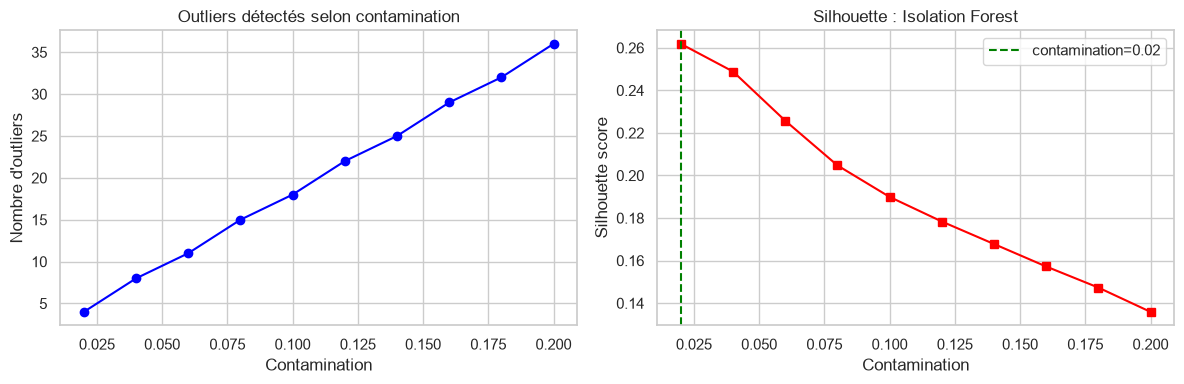

Contamination optimale : 0.02 → silhouette = 0.2618


In [47]:
contamination_values = np.arange(0.02, 0.21, 0.02)
results_if = []

for cont in contamination_values:
    iso = IsolationForest(contamination=cont, random_state=RANDOM_STATE)
    preds = iso.fit_predict(X_scaled)  # 1 = inlier, -1 = outlier
    n_outliers = (preds == -1).sum()
    
    # Silhouette sur les inliers uniquement (clustering binaire inlier/outlier)
    if len(set(preds)) == 2:
        sil = silhouette_score(X_scaled, preds)
        results_if.append({'contamination': round(cont, 2), 'n_outliers': n_outliers, 'pct_outliers': round(cont * 100, 1), 'silhouette': sil})

df_if_results = pd.DataFrame(results_if)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_if_results['contamination'], df_if_results['n_outliers'], 'bo-')
axes[0].set_xlabel('Contamination')
axes[0].set_ylabel('Nombre d\'outliers')
axes[0].set_title('Outliers détectés selon contamination')

axes[1].plot(df_if_results['contamination'], df_if_results['silhouette'], 'rs-')
axes[1].set_xlabel('Contamination')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette : Isolation Forest')

best_cont = df_if_results.loc[df_if_results['silhouette'].idxmax(), 'contamination']
axes[1].axvline(best_cont, color='green', linestyle='--', label=f'contamination={best_cont}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Contamination optimale : {best_cont} → silhouette = {df_if_results['silhouette'].max():.4f}")

### 5.2 Détection d'anomalies avec contamination optimale

In [48]:
iso_best = IsolationForest(contamination=best_cont, random_state=RANDOM_STATE)
labels_if = iso_best.fit_predict(X_scaled)  # 1 = normal, -1 = anomalie
scores_if = iso_best.decision_function(X_scaled)  # score d'anomalie (plus bas = plus anormal)

n_outliers = (labels_if == -1).sum()
print(f"Outliers détectés : {n_outliers} ({n_outliers/len(labels_if):.1%} du dataset)")
print(f"Silhouette : {silhouette_score(X_scaled, labels_if):.4f}")

Outliers détectés : 4 (2.2% du dataset)
Silhouette : 0.2618


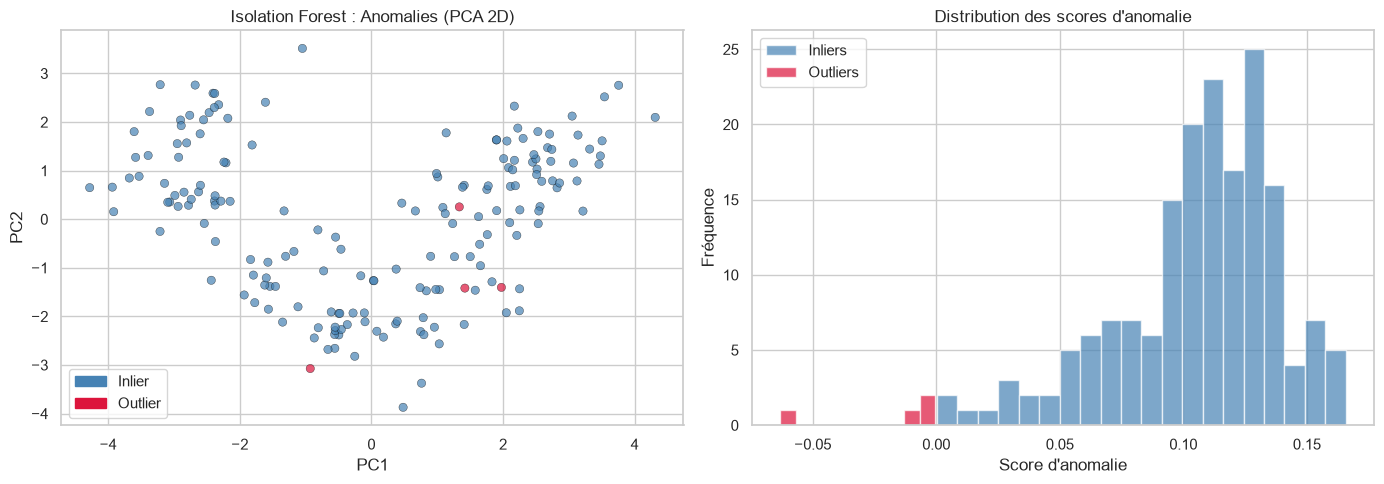

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA : inliers vs outliers
colors_if = ['steelblue' if l == 1 else 'crimson' for l in labels_if]
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_if, alpha=0.7, edgecolors='k', linewidths=0.3)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='steelblue', label='Inlier'), Patch(color='crimson', label='Outlier')])
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Isolation Forest : Anomalies (PCA 2D)')

# Score d'anomalie
axes[1].hist(scores_if[labels_if == 1], bins=20, color='steelblue', alpha=0.7, label='Inliers')
axes[1].hist(scores_if[labels_if == -1], bins=10, color='crimson', alpha=0.7, label='Outliers')
axes[1].set_xlabel('Score d\'anomalie')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des scores d\'anomalie')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.3 Isolation Forest + K-Means : clustering des inliers
On peut combiner les deux : filtrer les anomalies avec Isolation Forest, puis clustériser les inliers.

Silhouette K-Means sur inliers : 0.2942 (vs 0.2849 sur tout le dataset)


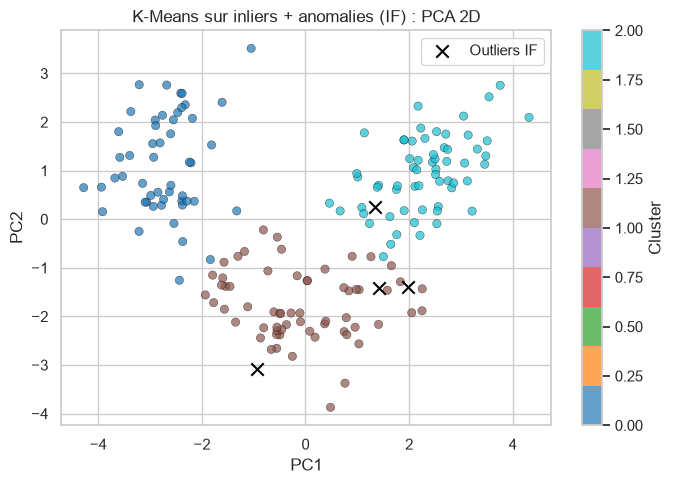

In [50]:
mask_inliers = labels_if == 1
X_inliers = X_scaled[mask_inliers]
X_pca_inliers = X_pca[mask_inliers]

km_inliers = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_combined = km_inliers.fit_predict(X_inliers)

sil_combined = silhouette_score(X_inliers, labels_combined)
print(f"Silhouette K-Means sur inliers : {sil_combined:.4f} (vs {silhouette_score(X_scaled, labels_kmeans):.4f} sur tout le dataset)")

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca_inliers[:, 0], X_pca_inliers[:, 1], c=labels_combined, cmap='tab10', alpha=0.7, edgecolors='k', linewidths=0.3)
# Outliers en fond
plt.scatter(X_pca[~mask_inliers, 0], X_pca[~mask_inliers, 1], marker='x', color='black', s=80, label='Outliers IF', zorder=5)
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means sur inliers + anomalies (IF) : PCA 2D')
plt.tight_layout()
plt.show()

---
## 6. CAH : Clustering Agglomératif Hiérarchique

La CAH construit un arbre (dendrogramme) en fusionnant itérativement les points les plus proches.  
Avantages : pas besoin de spécifier k à l'avance, visualisation hiérarchique des groupes.

Paramètre clé : `linkage` (critère de fusion) - ward, complete, average, single.

### 6.1 Dendrogramme

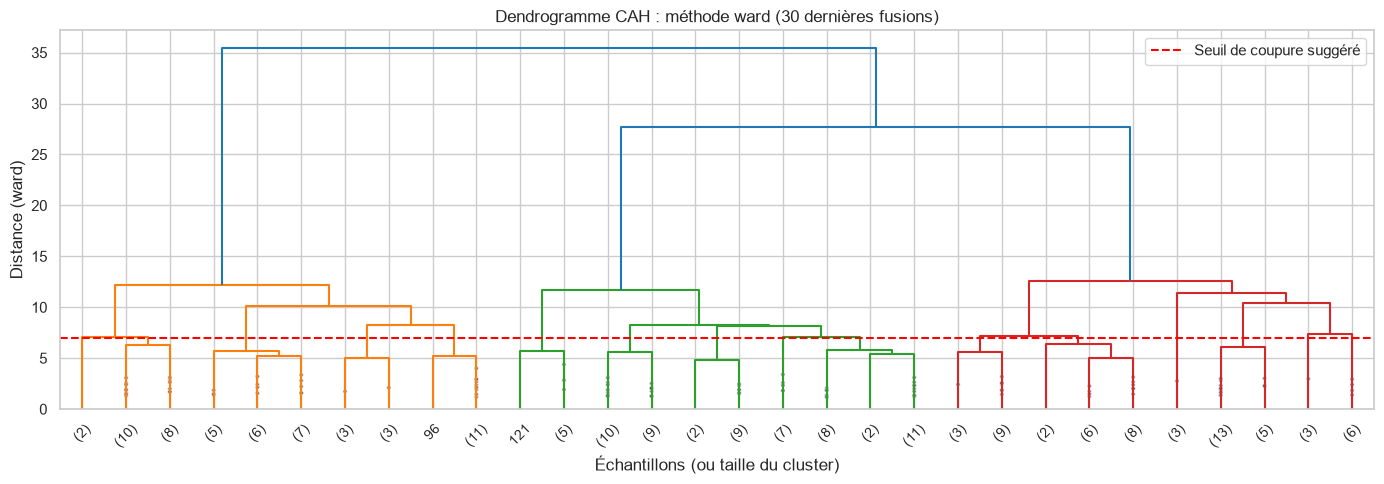

In [51]:
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage
from sklearn.cluster import AgglomerativeClustering

# Dendrogramme avec linkage ward sur les données normalisées
Z = scipy_linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=45, leaf_font_size=10, show_contracted=True)
plt.axhline(y=7, color='red', linestyle='--', label='Seuil de coupure suggéré')
plt.xlabel('Échantillons (ou taille du cluster)')
plt.ylabel('Distance (ward)')
plt.title('Dendrogramme CAH : méthode ward (30 dernières fusions)')
plt.legend()
plt.tight_layout()
plt.show()

### 6.2 Optimisation : linkage × n_clusters via silhouette

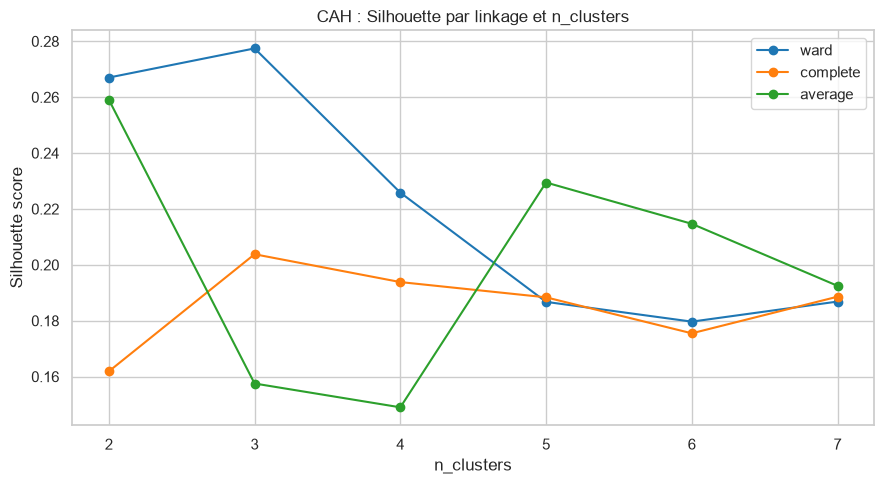

Meilleure config : linkage=ward, n_clusters=3 → silhouette=0.2774


In [52]:
linkage_methods = ['ward', 'complete', 'average']
n_clusters_range = range(2, 8)
results_cah = []

for method in linkage_methods:
    for n in n_clusters_range:
        cah = AgglomerativeClustering(n_clusters=n, linkage=method)
        labels = cah.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        results_cah.append({'linkage': method, 'n_clusters': n, 'silhouette': sil})

df_cah_results = pd.DataFrame(results_cah)

# Courbes silhouette par méthode de linkage
plt.figure(figsize=(9, 5))
for method in linkage_methods:
    subset = df_cah_results[df_cah_results['linkage'] == method]
    plt.plot(subset['n_clusters'], subset['silhouette'], marker='o', label=method)

plt.xlabel('n_clusters')
plt.ylabel('Silhouette score')
plt.title('CAH : Silhouette par linkage et n_clusters')
plt.legend()
plt.tight_layout()
plt.show()

best_cah = df_cah_results.loc[df_cah_results['silhouette'].idxmax()]
print(f"Meilleure config : linkage={best_cah['linkage']}, n_clusters={int(best_cah['n_clusters'])} → silhouette={best_cah['silhouette']:.4f}")

### 6.3 Entraînement avec la config optimale

Silhouette CAH : 0.2774
Distribution des clusters :
0    58
1    56
2    64
Name: count, dtype: int64


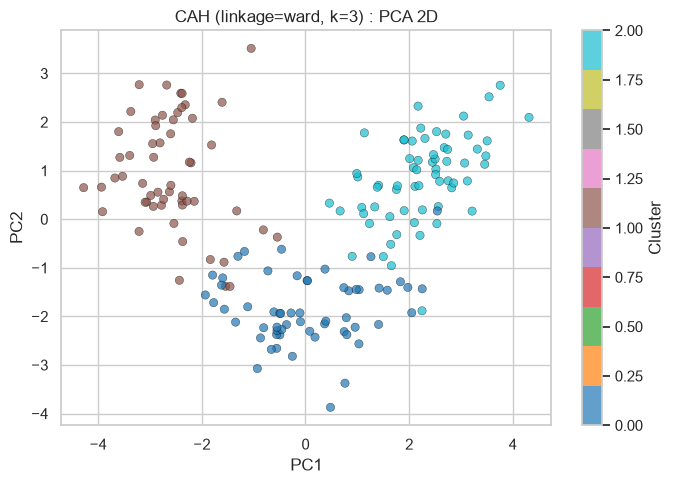

In [53]:
cah_best = AgglomerativeClustering(
    n_clusters=int(best_cah['n_clusters']),
    linkage=best_cah['linkage']
)
labels_cah = cah_best.fit_predict(X_scaled)

print(f"Silhouette CAH : {silhouette_score(X_scaled, labels_cah):.4f}")
print("Distribution des clusters :")
print(pd.Series(labels_cah).value_counts().sort_index())

# Visualisation PCA
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_cah, cmap='tab10', alpha=0.7, edgecolors='k', linewidths=0.3)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f"CAH (linkage={best_cah['linkage']}, k={int(best_cah['n_clusters'])}) : PCA 2D")
plt.tight_layout()
plt.show()

---
## 7. Qualification des clusters (K-Means)

La qualification consiste à **caractériser chaque cluster** : quelles features le distinguent ?  
On travaille sur les résultats K-Means qui produisent les clusters les plus interprétables.

In [54]:
df_qualified = df_raw.copy()
df_qualified['cluster_kmeans'] = labels_kmeans

# Moyennes par cluster (données non normalisées = interprétables)
profile = df_qualified.groupby('cluster_kmeans').mean().round(2)
profile

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
cluster_kmeans,,,,,,,,,,,,,
0,12.25,1.90,2.23,20.06,92.74,2.25,2.05,0.36,1.62,2.97,1.06,2.80,510.17
1,13.13,3.31,2.42,21.24,98.67,1.68,0.82,0.45,1.15,7.23,0.69,1.70,619.06
2,13.68,2.00,2.47,17.46,107.97,2.85,3.00,0.29,1.92,5.45,1.07,3.16,1100.23


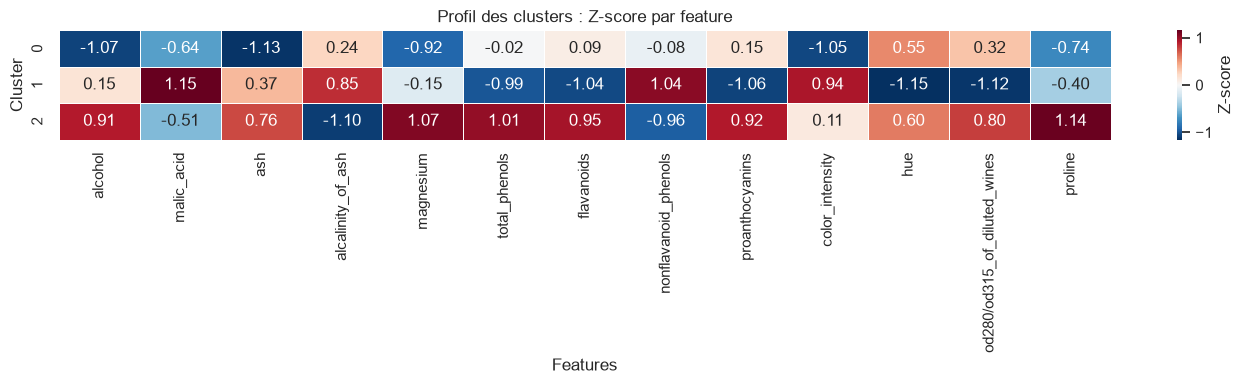

In [55]:
# Heatmap des profils normalisés (z-score relatif aux clusters)
profile_z = (profile - profile.mean()) / profile.std()

plt.figure(figsize=(14, 4))
sns.heatmap(profile_z, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5, cbar_kws={'label': 'Z-score'})
plt.title('Profil des clusters : Z-score par feature')
plt.xlabel('Features')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [56]:
# Top features discriminantes par cluster (écart à la moyenne globale)
global_mean = df_raw.mean()

for cluster_id in sorted(df_qualified['cluster_kmeans'].unique()):
    cluster_mean = df_qualified[df_qualified['cluster_kmeans'] == cluster_id][df_raw.columns].mean()
    diff = ((cluster_mean - global_mean) / global_mean * 100).sort_values(key=abs, ascending=False)
    print(f"\n--- Cluster {cluster_id} ({(labels_kmeans == cluster_id).sum()} vins) ---")
    print(diff.head(5).to_string())


--- Cluster 0 (65 vins) ---
color_intensity                -41.221351
proline                        -31.694492
malic_acid                     -18.788453
hue                             10.993610
od280/od315_of_diluted_wines     7.340058

--- Cluster 1 (51 vins) ---
flavanoids                     -59.649349
color_intensity                 43.032371
malic_acid                      41.556586
od280/od315_of_diluted_wines   -35.035565
proanthocyanins                -27.972647

--- Cluster 2 (62 vins) ---
flavanoids                      47.995403
proline                         47.306967
total_phenols                   24.071514
od280/od315_of_diluted_wines    21.124355
proanthocyanins                 20.818287


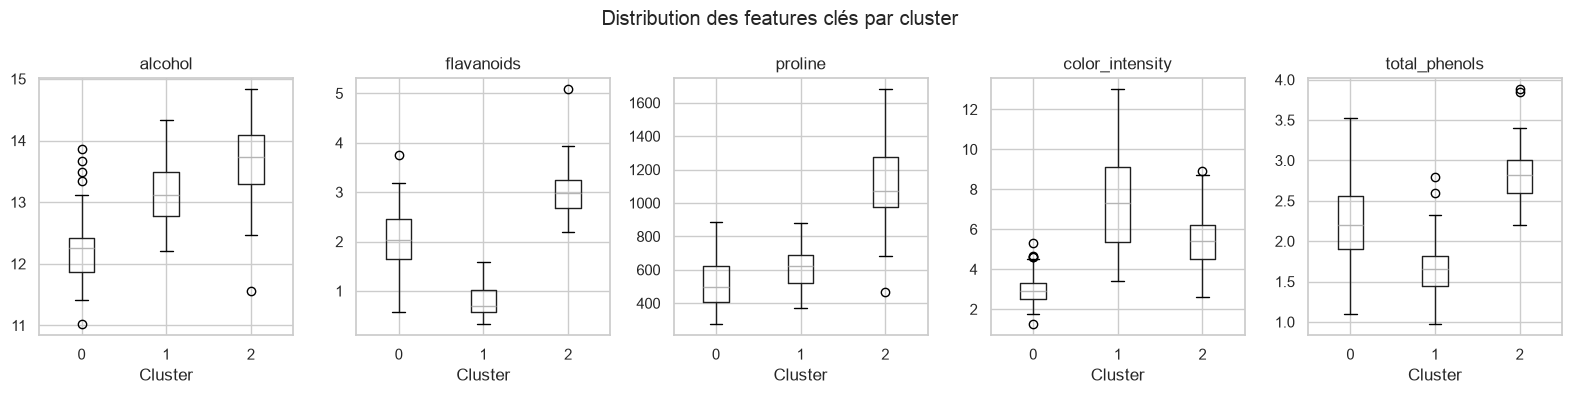

In [57]:
# Boxplots des features les plus discriminantes
top_features = ['alcohol', 'flavanoids', 'proline', 'color_intensity', 'total_phenols']

fig, axes = plt.subplots(1, len(top_features), figsize=(16, 4))

for ax, feat in zip(axes, top_features):
    df_qualified.boxplot(column=feat, by='cluster_kmeans', ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('Cluster')

plt.suptitle('Distribution des features clés par cluster')
plt.tight_layout()
plt.show()

---
## 8. Comparaison des modèles

In [58]:
results_summary = [
    {
        'Modèle': 'K-Means',
        'Paramètres optimaux': f'k={best_k}',
        'N clusters': best_k,
        'N outliers/bruit': 0,
        'Silhouette': round(silhouette_score(X_scaled, labels_kmeans), 4)
    },
    {
        'Modèle': 'DBSCAN',
        'Paramètres optimaux': f'eps={best_dbscan["eps"]:.2f}, min_s={int(best_dbscan["min_samples"])}',
        'N clusters': int(best_dbscan['n_clusters']),
        'N outliers/bruit': int(best_dbscan['n_noise']),
        'Silhouette': round(best_dbscan['silhouette'], 4)
    },
    {
        'Modèle': 'Isolation Forest',
        'Paramètres optimaux': f'contamination={best_cont}',
        'N clusters': 2,
        'N outliers/bruit': int((labels_if == -1).sum()),
        'Silhouette': round(silhouette_score(X_scaled, labels_if), 4)
    },
    {
        'Modèle': 'K-Means (post-IF)',
        'Paramètres optimaux': f'k={best_k} sur inliers',
        'N clusters': best_k,
        'N outliers/bruit': int((labels_if == -1).sum()),
        'Silhouette': round(sil_combined, 4)
    }
,
    {
        'Modèle': 'CAH',
        'Paramètres optimaux': f"linkage={best_cah['linkage']}, k={int(best_cah['n_clusters'])}",
        'N clusters': int(best_cah['n_clusters']),
        'N outliers/bruit': 0,
        'Silhouette': round(silhouette_score(X_scaled, labels_cah), 4)
    },
]

df_summary = pd.DataFrame(results_summary)
df_summary

,Modèle,Paramètres optimaux,N clusters,N outliers/bruit,Silhouette
0,K-Means,k=3,3,0,0.2849
1,DBSCAN,"eps=2.50, min_s=10",2,32,0.2044
2,Isolation Forest,contamination=0.02,2,4,0.2618
3,K-Means (post-IF),k=3 sur inliers,3,4,0.2942
4,CAH,"linkage=ward, k=3",3,0,0.2774


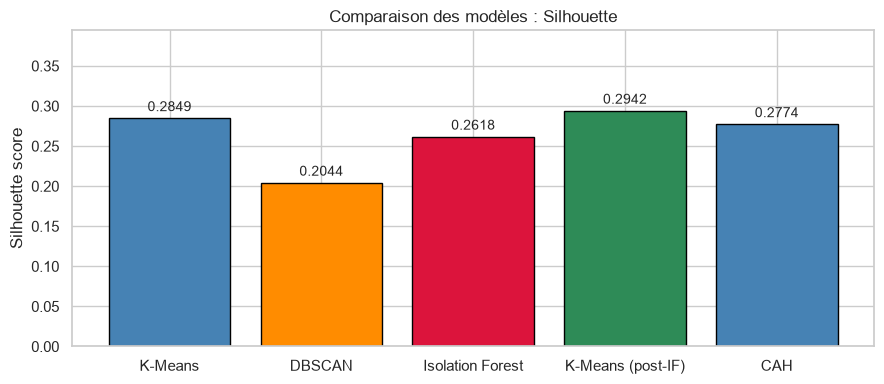

In [59]:
plt.figure(figsize=(9, 4))
bars = plt.bar(df_summary['Modèle'], df_summary['Silhouette'], color=['steelblue', 'darkorange', 'crimson', 'seagreen'], edgecolor='k')
for bar, val in zip(bars, df_summary['Silhouette']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.ylim(0, max(df_summary['Silhouette']) + 0.1)
plt.ylabel('Silhouette score')
plt.title('Comparaison des modèles : Silhouette')
plt.tight_layout()
plt.show()

---
## 9. Validation : retrouve-t-on les vrais cépages ?

Les vraies étiquettes existent dans le dataset sklearn (`target` : 3 cépages).  
On les utilise ici **uniquement pour évaluation a posteriori** : elles n'ont pas été utilisées pendant l'entraînement.

In [60]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

try:
    true_labels  # défini plus haut si sklearn fallback
except NameError:
    true_labels = load_wine().target

models = {
    'K-Means': labels_kmeans,
    'DBSCAN': labels_dbscan,
    'Isolation Forest': labels_if,
    'CAH': labels_cah,
}

print(f"{'Modèle':<20} {'ARI':>8} {'NMI':>8}")
print('-' * 38)
for name, preds in models.items():
    ari = adjusted_rand_score(true_labels, preds)
    nmi = normalized_mutual_info_score(true_labels, preds)
    print(f"{name:<20} {ari:>8.4f} {nmi:>8.4f}")

print("\nARI=1 et NMI=1 = clustering parfait par rapport aux vrais labels")

Modèle                    ARI      NMI
--------------------------------------
K-Means                0.8975   0.8759
DBSCAN                 0.4235   0.5310
Isolation Forest      -0.0064   0.0353
CAH                    0.7899   0.7865

ARI=1 et NMI=1 = clustering parfait par rapport aux vrais labels


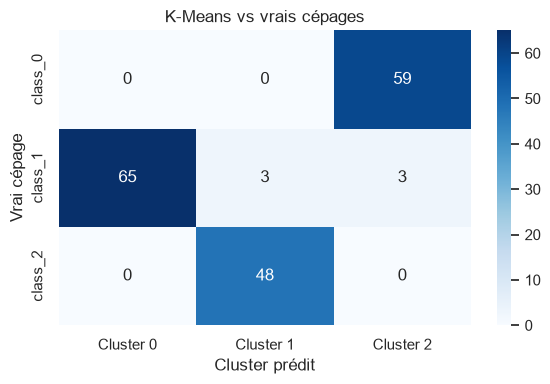

In [61]:
# Matrice de confusion : clusters K-Means vs vrais cépages
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(true_labels, labels_kmeans)
wine = load_wine()

plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Cluster {i}' for i in range(best_k)],
            yticklabels=wine.target_names)
plt.title('K-Means vs vrais cépages')
plt.xlabel('Cluster prédit')
plt.ylabel('Vrai cépage')
plt.tight_layout()
plt.show()

---
## 10. Conclusion

| Critère | K-Means | DBSCAN | Isolation Forest | CAH |
|---|---|---|---|---|
| Type | Partitionnel | Densité | Détection d'anomalies | Hiérarchique |
| Nombre de clusters | Fixé (k) | Automatique | Binaire (inlier/outlier) | Libre (dendrogramme) |
| Gère le bruit | Non | Oui | Oui | Non |
| Forme des clusters | Sphérique | Arbitraire | N/A | Dépend du linkage |
| Scalabilité | Très bonne | Moyenne | Bonne | Faible (O(n²)) |
| Interprétabilité | ★★★ | ★★ | ★★★ (scores) | ★★★★ (dendrogramme) |

**À retenir :**
- K-Means performe bien sur ce dataset (clusters relativement sphériques, tailles similaires)
- DBSCAN détecte des outliers naturellement : utile pour identifier des vins atypiques
- Isolation Forest complète les deux en isolant les anomalies avant clustering
- La combinaison IF → K-Means peut améliorer la qualité du clustering final

**Pistes d'exploration :**
- Tester avec PCA à n composantes (variance expliquée > 95%) avant K-Means
- Comparer avec `AgglomerativeClustering` (hiérarchique)
- Utiliser `UMAP` à la place de PCA pour la visualisation